In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve project root
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find the project root.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Load cleaned tables needed for EDA
orders = pd.read_csv(PROCESSED_DIR / "orders.csv")
order_items = pd.read_csv(PROCESSED_DIR / "order_items.csv")

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)

Orders: (99441, 8)
Order Items: (112647, 7)


In [2]:
# Convert purchase timestamp to datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

# Calculate total order value from order items
order_revenue = (
    order_items
    .groupby("order_id", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "order_revenue"})
)

# Join revenue with order purchase date
revenue_data = orders[
    ["order_id", "order_purchase_timestamp"]
].merge(
    order_revenue,
    on="order_id",
    how="inner"
)

# Create monthly revenue
monthly_revenue = (
    revenue_data
    .set_index("order_purchase_timestamp")
    .resample("ME")["order_revenue"]
    .sum()
    .reset_index()
)

print(monthly_revenue.head())
print("\nNumber of months:", len(monthly_revenue))
print("\nTotal revenue: ₹", round(monthly_revenue["order_revenue"].sum(), 2))

  order_purchase_timestamp  order_revenue
0               2016-09-30         267.36
1               2016-10-31       49507.66
2               2016-11-30           0.00
3               2016-12-31          10.90
4               2017-01-31      120312.87

Number of months: 25

Total revenue: ₹ 13591051.9


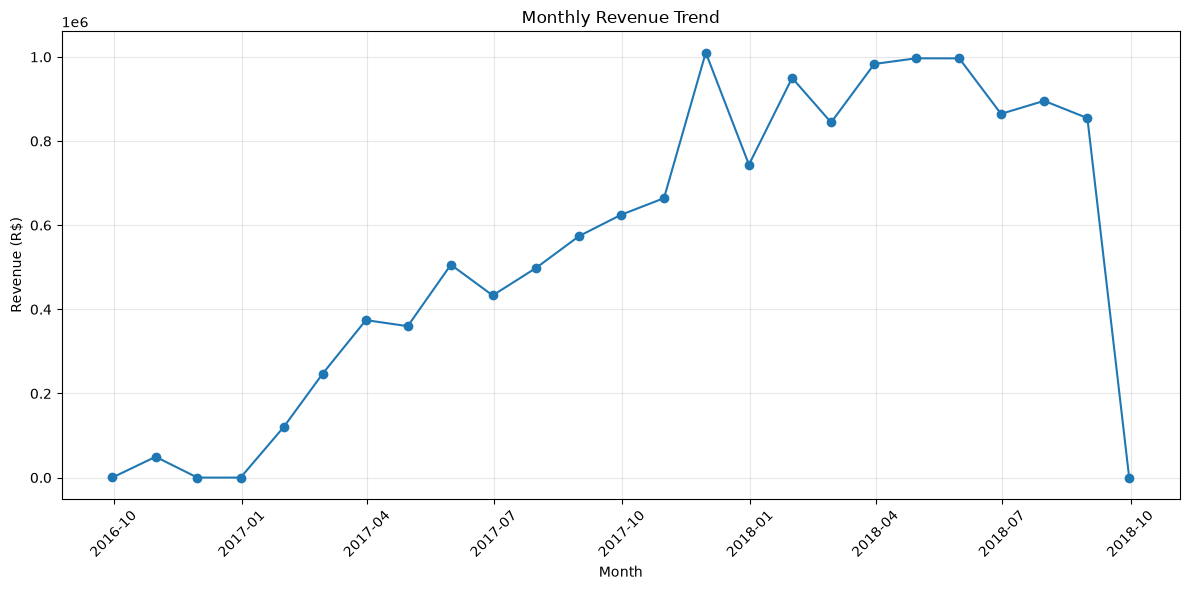

In [3]:
# Revenue trend over time — monthly

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["order_purchase_timestamp"],
    monthly_revenue["order_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [4]:
# Check the date range and revenue in the final months

print("Earliest order date:")
print(orders["order_purchase_timestamp"].min())

print("\nLatest order date:")
print(orders["order_purchase_timestamp"].max())

print("\nLast 5 months of revenue:")
print(monthly_revenue.tail())

Earliest order date:
2016-09-04 21:15:00

Latest order date:
2018-10-17 17:30:00

Last 5 months of revenue:
   order_purchase_timestamp  order_revenue
20               2018-05-31      996517.68
21               2018-06-30      864652.51
22               2018-07-31      895507.22
23               2018-08-31      854566.33
24               2018-09-30         145.00


In [5]:
# Investigate the final months

revenue_data["month"] = revenue_data["order_purchase_timestamp"].dt.to_period("M")

final_months = (
    revenue_data
    .groupby("month")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_revenue", "sum")
    )
    .tail(5)
)

print(final_months)

print("\nOrders by purchase month in the original orders table:")
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")

print(
    orders.groupby("month")
    .size()
    .tail(5)
)

         orders    revenue
month                     
2018-05    6853  996517.68
2018-06    6159  864652.51
2018-07    6273  895507.22
2018-08    6451  854566.33
2018-09       1     145.00

Orders by purchase month in the original orders table:
month
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64


In [6]:
# Keep only complete months for the revenue trend
# September 2018 onward has incomplete order coverage.

complete_revenue = monthly_revenue[
    monthly_revenue["order_purchase_timestamp"] < "2018-09-01"
].copy()

print("Revenue trend period:")
print(
    complete_revenue["order_purchase_timestamp"].min(),
    "to",
    complete_revenue["order_purchase_timestamp"].max()
)

print("\nTotal revenue represented:")
print(f"R$ {complete_revenue['order_revenue'].sum():,.2f}")

Revenue trend period:
2016-09-30 00:00:00 to 2018-08-31 00:00:00

Total revenue represented:
R$ 13,590,906.90


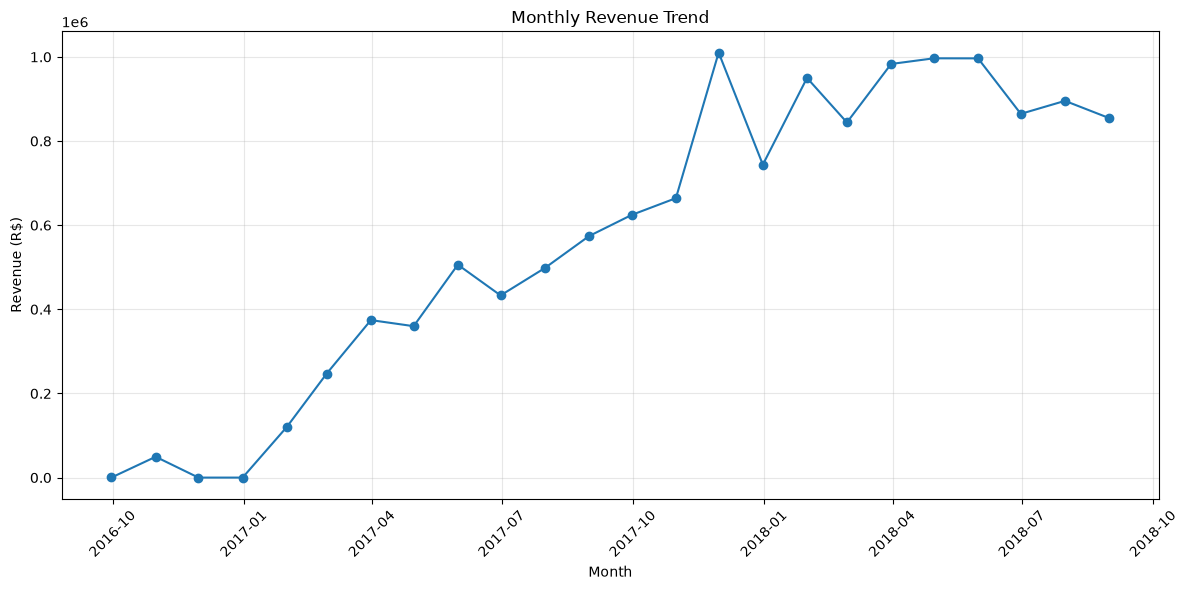

In [7]:
# Monthly Revenue Trend — Complete Months

plt.figure(figsize=(12, 6))

plt.plot(
    complete_revenue["order_purchase_timestamp"],
    complete_revenue["order_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Takeaway: Monthly revenue increased strongly from early 2017 and reached approximately R$1.0M per month by late 2017–2018, while the final September–October 2018 records are incomplete and were excluded from trend interpretation.


Incomplete data coverage: September–October 2018 contain very few orders compared with previous months, so the apparent revenue collapse should not be treated as a genuine business decline.

In [8]:
# Level 3 — #2 Order Volume Over Time

# Count unique orders by month
monthly_orders = (
    orders
    .groupby("month")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

# Convert Period to timestamp for plotting
monthly_orders["month"] = monthly_orders["month"].dt.to_timestamp()

print("Monthly order volume:")
print(monthly_orders.head())

print("\nLast 5 months:")
print(monthly_orders.tail())

Monthly order volume:
       month  order_count
0 2016-09-01            4
1 2016-10-01          324
2 2016-12-01            1
3 2017-01-01          800
4 2017-02-01         1780

Last 5 months:
        month  order_count
20 2018-06-01         6167
21 2018-07-01         6292
22 2018-08-01         6512
23 2018-09-01           16
24 2018-10-01            4


In [9]:
# Check the final months for incomplete data

print("Order volume in the final months:")
print(
    monthly_orders.tail(6).to_string(index=False)
)

Order volume in the final months:
     month  order_count
2018-05-01         6873
2018-06-01         6167
2018-07-01         6292
2018-08-01         6512
2018-09-01           16
2018-10-01            4


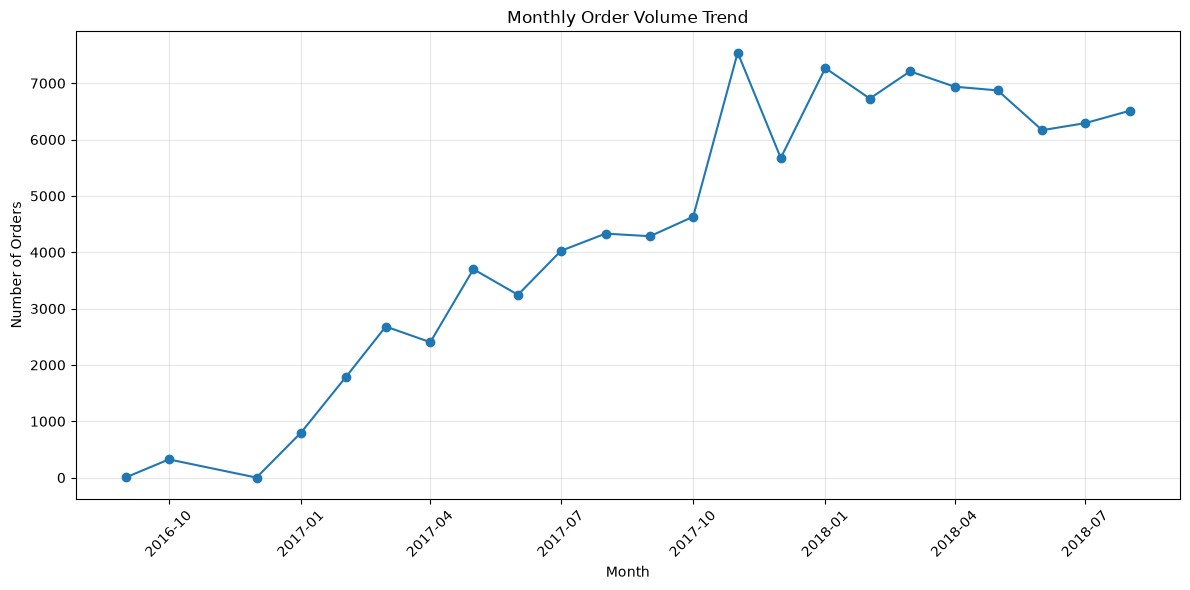

In [10]:
# Exclude incomplete final months from the trend chart
complete_orders = monthly_orders[
    monthly_orders["month"] < "2018-09-01"
].copy()

# Monthly Order Volume Trend

plt.figure(figsize=(12, 6))

plt.plot(
    complete_orders["month"],
    complete_orders["order_count"],
    marker="o"
)

plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


Takeaway: Monthly order volume grew substantially from 2016 through 2017 and stabilized at roughly 6,000–7,000 orders per month during 2018, while September–October 2018 contain incomplete data and were excluded from trend interpretation.

Investigation point


Incomplete order coverage: September–October 2018 contain only 16 and 4 orders respectively, so the apparent decline in order volume is a data-coverage issue rather than evidence of falling demand.


In [11]:
# Level 3 — #3 Order Value Distribution

# Calculate total product value for each order
order_values = (
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_value")
)

print("Order value statistics:")
print(order_values["order_value"].describe())

Order value statistics:
count    98664.000000
mean       137.750871
std        210.644588
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: order_value, dtype: float64


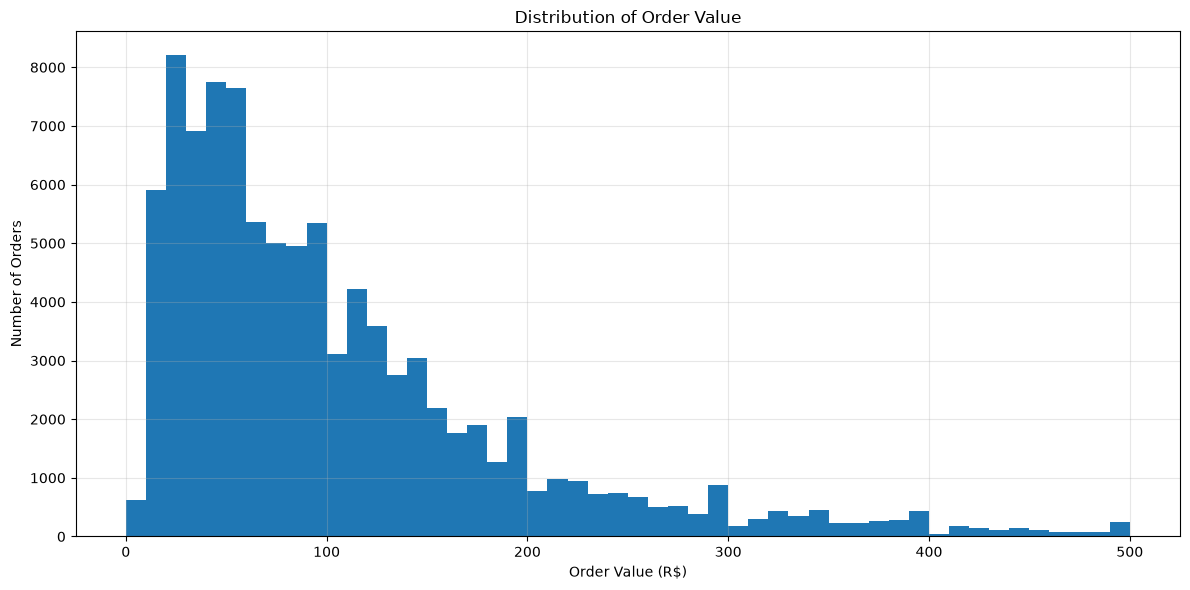

In [12]:
# Order Value Distribution

plt.figure(figsize=(12, 6))

plt.hist(
    order_values["order_value"],
    bins=50,
    range=(0, 500)
)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value (R$)")
plt.ylabel("Number of Orders")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


Takeaway: Order values are strongly right-skewed: the median order is R$86.90, while the mean is R$137.75, indicating that a relatively small number of high-value orders increase the average.


High-value orders: A small number of orders are much larger than typical orders, with the maximum reaching R$13,440; these orders are worth investigating to understand which products or categories drive unusually high order values.

In [13]:
# Level 3 — #4 Delivery Time Distribution

# Make sure both columns are datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"],
    errors="coerce"
)

# Calculate delivery time in days
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

# Keep valid delivery times only
delivery_times = orders[
    orders["delivery_time_days"].notna()
    & (orders["delivery_time_days"] >= 0)
].copy()

print("Valid delivery records:", len(delivery_times))

print("\nDelivery time statistics:")
print(delivery_times["delivery_time_days"].describe())

Valid delivery records: 96476

Delivery time statistics:
count    96476.000000
mean        12.558658
std          9.546533
min          0.533333
25%          6.766493
50%         10.218056
75%         15.720139
max        209.628472
Name: delivery_time_days, dtype: float64


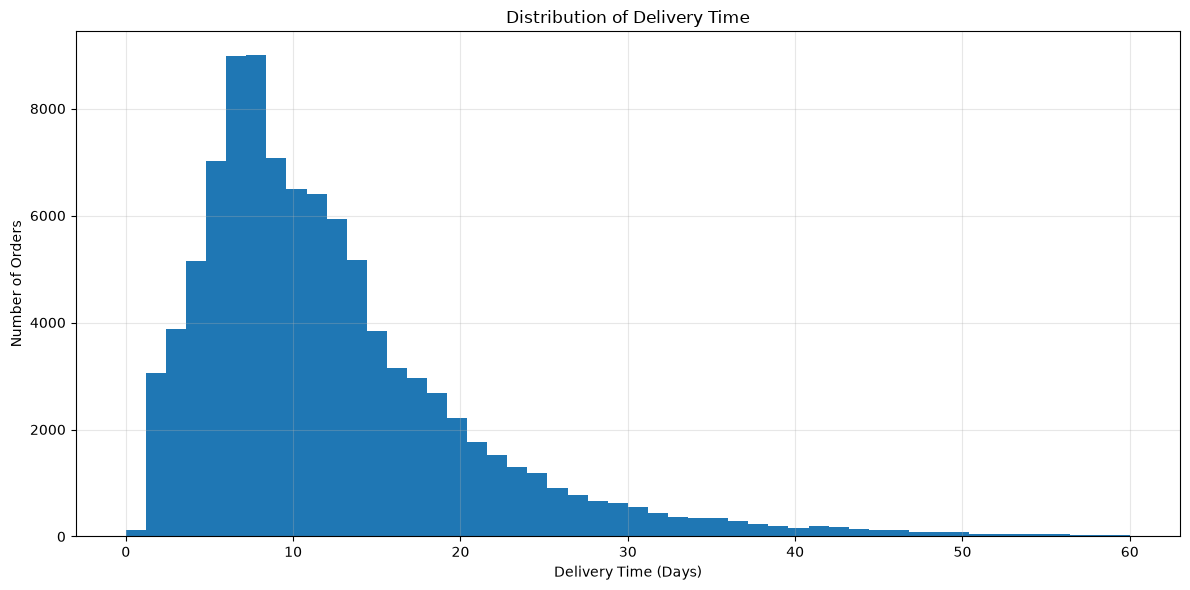

In [14]:
# Delivery Time Distribution

plt.figure(figsize=(12, 6))

plt.hist(
    delivery_times["delivery_time_days"],
    bins=50,
    range=(0, 60)
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


Takeaway: Delivery time is right-skewed, with a median of 10.2 days and 75% of deliveries completed within approximately 15.7 days, while a small number of extreme deliveries take much longer.


Extreme delivery delays: A small number of orders have exceptionally long delivery times, with the maximum exceeding 209 days, which should be investigated for operational or data-quality issues.

In [15]:
# Load the cleaned reviews table

order_reviews = pd.read_csv(
    PROCESSED_DIR / "order_reviews.csv"
)

print("Order Reviews:", order_reviews.shape)

Order Reviews: (99222, 7)


In [16]:
# Level 3 — #5 Review Score Distribution

# Count each review score
review_scores = (
    order_reviews["review_score"]
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
    .reset_index()
)

review_scores.columns = ["review_score", "review_count"]

print("Review score distribution:")
print(review_scores)

print("\nTotal reviews:", review_scores["review_count"].sum())

Review score distribution:
   review_score  review_count
0             1         11424
1             2          3151
2             3          8179
3             4         19141
4             5         57327

Total reviews: 99222


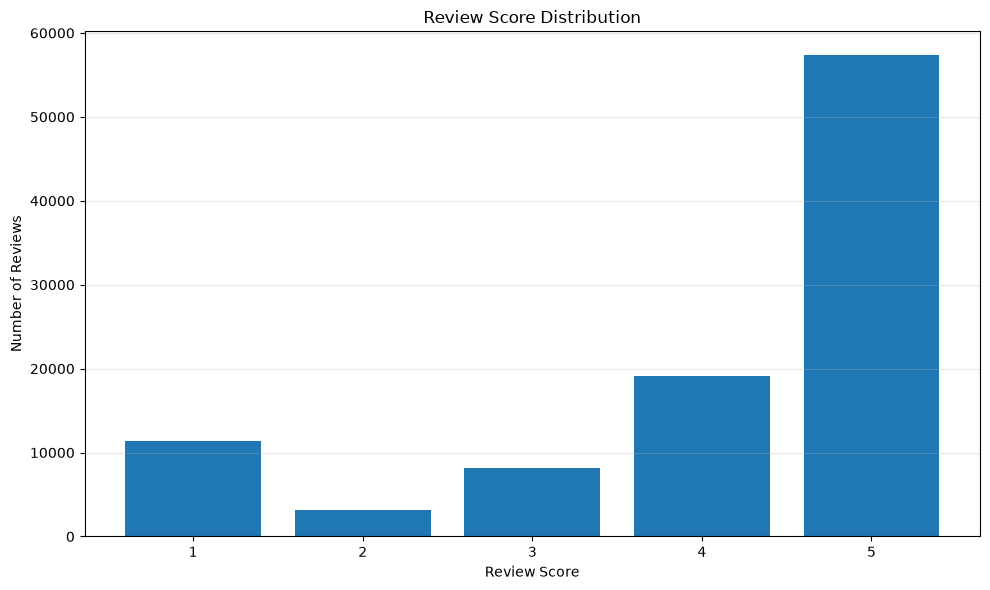

In [17]:
# Review Score Distribution

plt.figure(figsize=(10, 6))

plt.bar(
    review_scores["review_score"],
    review_scores["review_count"]
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Takeaway: Review scores are strongly concentrated at the positive end, with 5-star reviews accounting for about 58% of all reviews, while 1–2 star reviews make up a much smaller share.

Low-review experience: Although 5-star reviews dominate, there are still more than 14,500 one- and two-star reviews, making it worth investigating which products, sellers, or delivery experiences are associated with poor ratings.

In [18]:
# Level 3 — #6 Payment Type Breakdown

# Load cleaned payment data
order_payments = pd.read_csv(
    PROCESSED_DIR / "order_payments.csv"
)

print("Order Payments:", order_payments.shape)

print("\nPayment types:")
print(order_payments["payment_type"].value_counts())

Order Payments: (103881, 5)

Payment types:
payment_type
credit_card    76794
boleto         19784
voucher         5771
debit_card      1529
not_defined        3
Name: count, dtype: int64


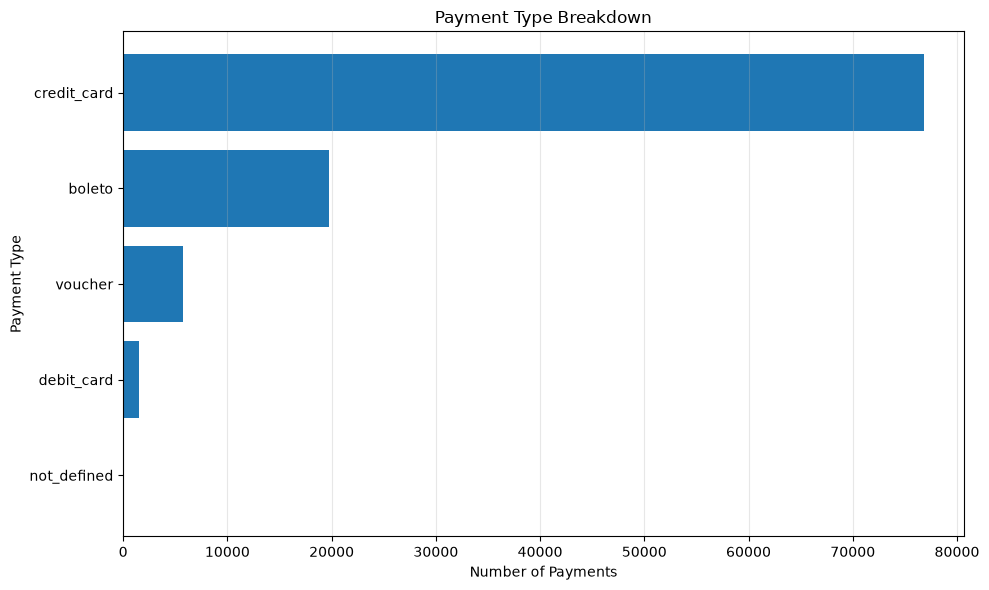

In [19]:
# Payment Type Breakdown

payment_counts = (
    order_payments["payment_type"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    payment_counts.index,
    payment_counts.values
)

plt.title("Payment Type Breakdown")
plt.xlabel("Number of Payments")
plt.ylabel("Payment Type")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

Takeaway: Credit cards dominate the payment methods, accounting for approximately 74% of payment records, followed by boleto at about 19%, while voucher and debit card payments represent much smaller shares.

Payment method concentration: Credit cards account for the vast majority of payment records, making it worth investigating whether payment method influences order value, installments, or customer behavior.

In [20]:
# Level 3 — #7 Revenue by Category — Top 10

# Load cleaned product and category translation tables
products = pd.read_csv(
    PROCESSED_DIR / "products.csv"
)

category_translation = pd.read_csv(
    PROCESSED_DIR / "category_translation.csv"
)

print("Products:", products.shape)
print("Category Translation:", category_translation.shape)

print("\nProduct columns:")
print(products.columns.tolist())

print("\nTranslation columns:")
print(category_translation.columns.tolist())

Products: (32951, 9)
Category Translation: (71, 2)

Product columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Translation columns:
['product_category_name', 'product_category_name_english']


In [21]:
# Join order items with products
items_with_category = order_items.merge(
    products[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

# Add English category names
items_with_category = items_with_category.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Calculate revenue by English category
category_revenue = (
    items_with_category
    .groupby(
        "product_category_name_english",
        dropna=False
    )["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.columns = [
    "category",
    "revenue"
]

print("Top 10 categories by revenue:")
print(
    category_revenue
    .head(10)
    .to_string(index=False)
)

print("\nCategories without an English translation:",
      category_revenue["category"].isna().sum())

Top 10 categories by revenue:
             category    revenue
        health_beauty 1258681.34
        watches_gifts 1204885.68
       bed_bath_table 1036988.68
       sports_leisure  988048.97
computers_accessories  911954.32
      furniture_decor  729762.49
           cool_stuff  635290.85
           housewares  632248.66
                 auto  592720.11
         garden_tools  485256.46

Categories without an English translation: 1


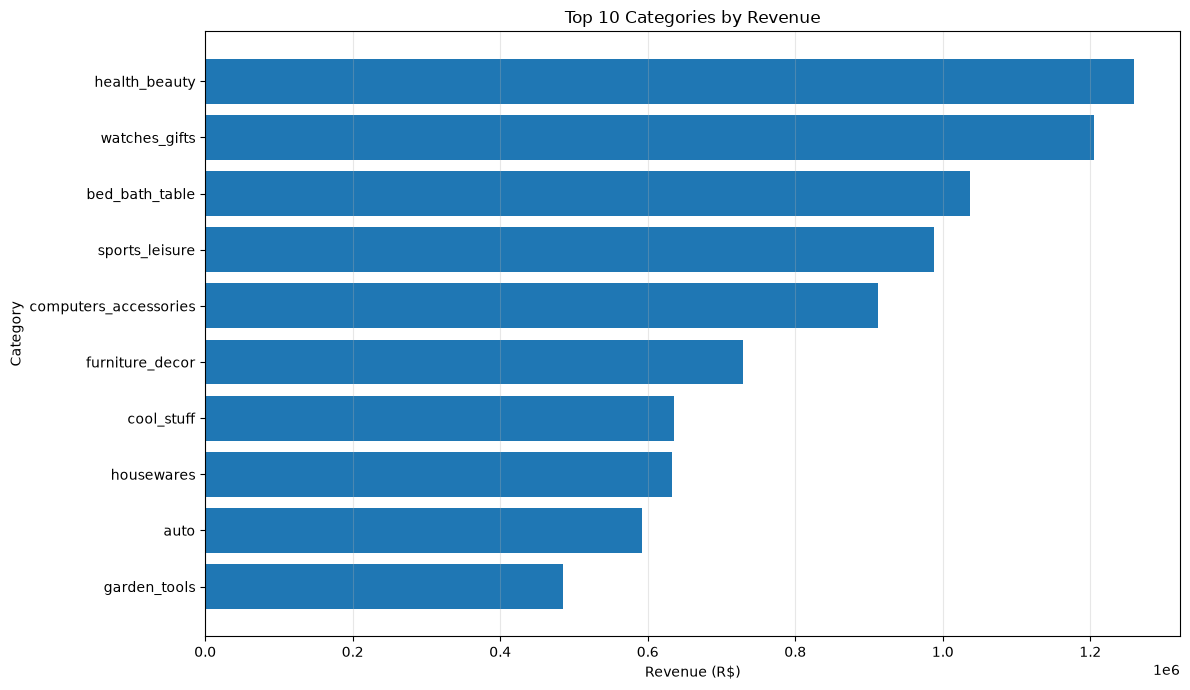

In [22]:
# Top 10 Revenue by Category

top_10_categories = (
    category_revenue
    .dropna(subset=["category"])
    .head(10)
    .sort_values("revenue", ascending=True)
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_categories["category"],
    top_10_categories["revenue"]
)

plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

Takeaway: Health & beauty generated the highest revenue at approximately R$1.26M, followed by watches & gifts at R$1.20M and bed & bath table at R$1.04M, showing that revenue is concentrated among a few leading categories.

Category concentration: Health & beauty and watches & gifts are the two highest-revenue categories; investigating their order volume, average order value, and product mix could explain what drives their strong performance.

Missing category translation: One product category has no English translation and should be reviewed to determine whether the missing translation affects category-level analysis.

In [23]:
# Level 3 — #8 Revenue by State

# Load cleaned customer data
customers = pd.read_csv(
    PROCESSED_DIR / "customers.csv"
)

print("Customers:", customers.shape)

print("\nCustomer columns:")
print(customers.columns.tolist())

Customers: (99441, 5)

Customer columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [24]:
# Join orders with customers to get customer state

orders_with_state = orders.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left",
    indicator=True
)

# Check whether every order found a customer
print("Join results:")
print(orders_with_state["_merge"].value_counts())

# Count orders without a matching customer
missing_customer_matches = (
    orders_with_state["_merge"] == "left_only"
).sum()

print("\nOrders without matching customer:", missing_customer_matches)

# Remove merge indicator after verification
orders_with_state = orders_with_state.drop(columns="_merge")

Join results:
_merge
both          99441
left_only         0
right_only        0
Name: count, dtype: int64

Orders without matching customer: 0


In [25]:
# Calculate revenue for each order
order_revenue = (
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_revenue")
)

# Add revenue to orders with customer state
orders_with_state = orders_with_state.merge(
    order_revenue,
    on="order_id",
    how="left"
)

# Calculate total revenue by customer state
state_revenue = (
    orders_with_state
    .groupby("customer_state")["order_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_revenue.columns = ["state", "revenue"]

print("Revenue by state:")
print(state_revenue.to_string(index=False))

Revenue by state:
state    revenue
   SP 5202363.25
   RJ 1824092.67
   MG 1585308.03
   RS  750304.02
   PR  683083.76
   SC  520553.34
   BA  511349.99
   DF  302603.94
   GO  294591.95
   ES  275037.31
   PE  262788.03
   CE  227254.71
   PA  178947.81
   MT  156453.53
   MA  119648.22
   MS  116812.64
   PB  115268.08
   PI   86914.08
   RN   83034.98
   AL   80314.81
   SE   58920.85
   TO   49621.74
   RO   46140.64
   AM   22356.84
   AC   15982.95
   AP   13474.30
   RR    7829.43


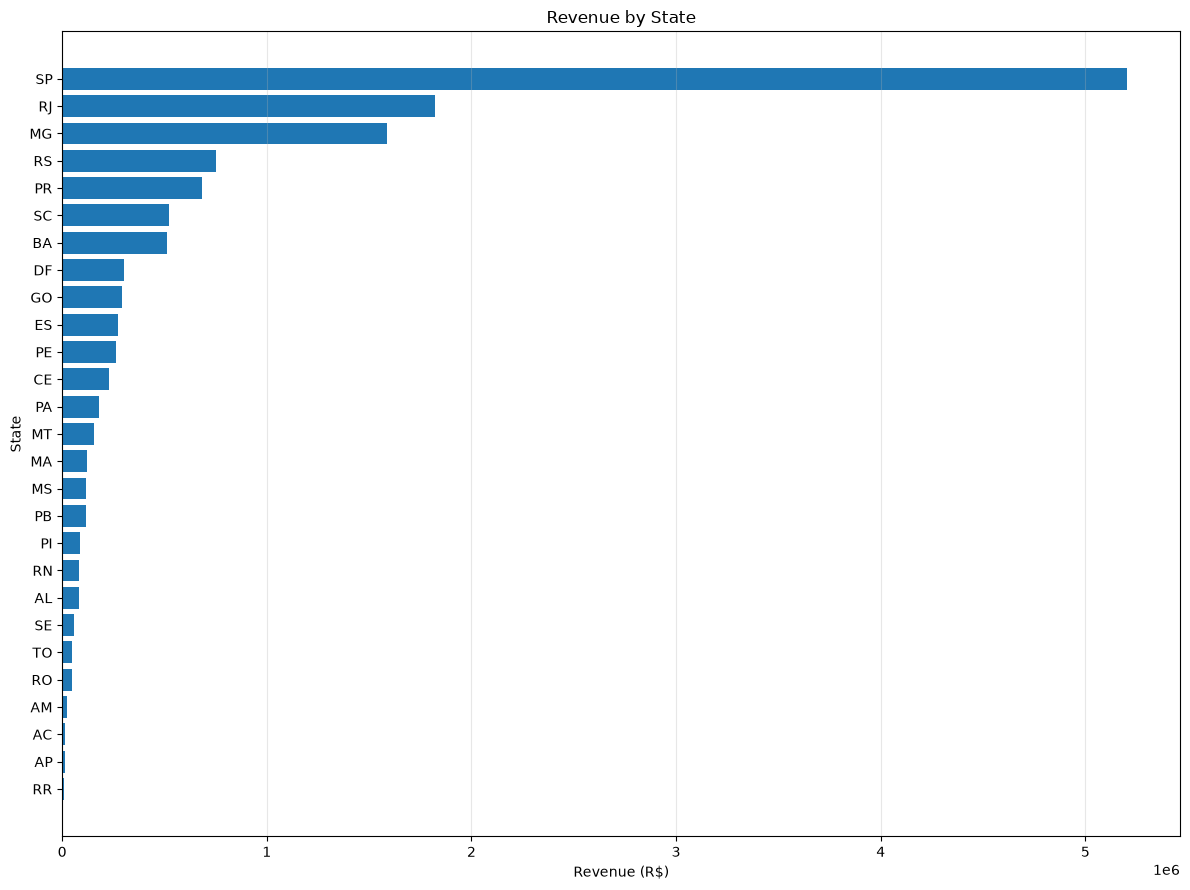

In [26]:
# Revenue by State

state_revenue_plot = (
    state_revenue
    .sort_values("revenue", ascending=True)
)

plt.figure(figsize=(12, 9))

plt.barh(
    state_revenue_plot["state"],
    state_revenue_plot["revenue"]
)

plt.title("Revenue by State")
plt.xlabel("Revenue (R$)")
plt.ylabel("State")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

Takeaway: São Paulo (SP) generates by far the highest revenue at approximately R$5.20M, followed by Rio de Janeiro (RJ) at R$1.82M and Minas Gerais (MG) at R$1.59M, showing strong geographic concentration of revenue.

Geographic concentration: São Paulo contributes substantially more revenue than any other state; investigating whether this is driven by customer population, order volume, or higher order values could reveal opportunities for regional growth.

In [27]:
# Level 3 — #9 Orders by Day of Week / Hour of Day

# Make sure purchase timestamp is datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

# Create day-of-week and hour-of-day features
orders["day_of_week"] = orders["order_purchase_timestamp"].dt.day_name()
orders["hour_of_day"] = orders["order_purchase_timestamp"].dt.hour

# Define the correct weekday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

print("Day of week:")
print(
    orders["day_of_week"]
    .value_counts()
    .reindex(weekday_order)
)

print("\nHour of day:")
print(
    orders["hour_of_day"]
    .value_counts()
    .sort_index()
)

Day of week:
day_of_week
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: count, dtype: int64

Hour of day:
hour_of_day
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1233
8     2965
9     4785
10    6177
11    6578
12    5995
13    6519
14    6568
15    6454
16    6676
17    6149
18    5769
19    5982
20    6193
21    6217
22    5817
23    4122
Name: count, dtype: int64


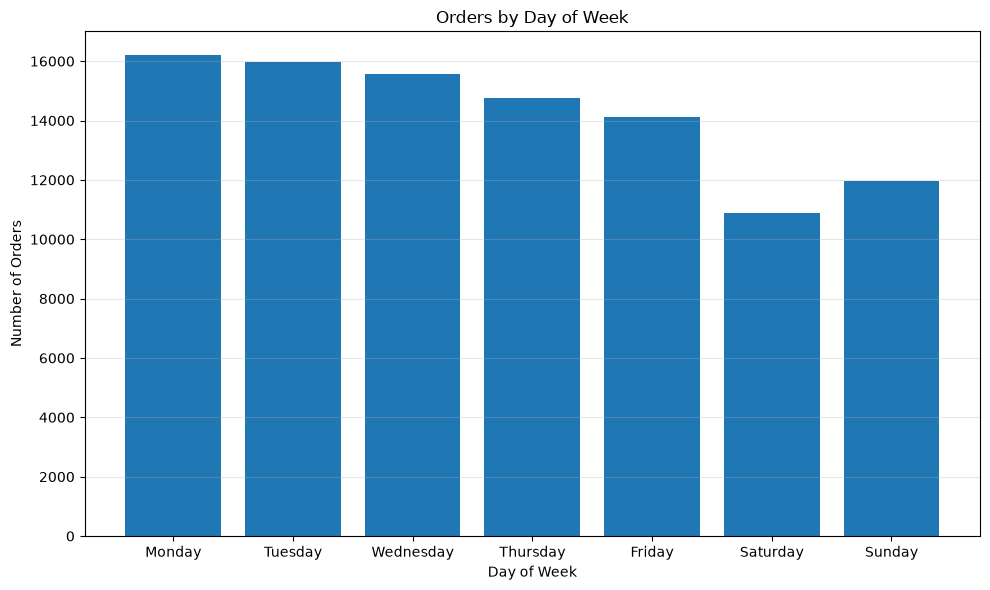

In [28]:
# Orders by Day of Week

daily_orders = (
    orders["day_of_week"]
    .value_counts()
    .reindex(weekday_order)
)

plt.figure(figsize=(10, 6))

plt.bar(
    daily_orders.index,
    daily_orders.values
)

plt.title("Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

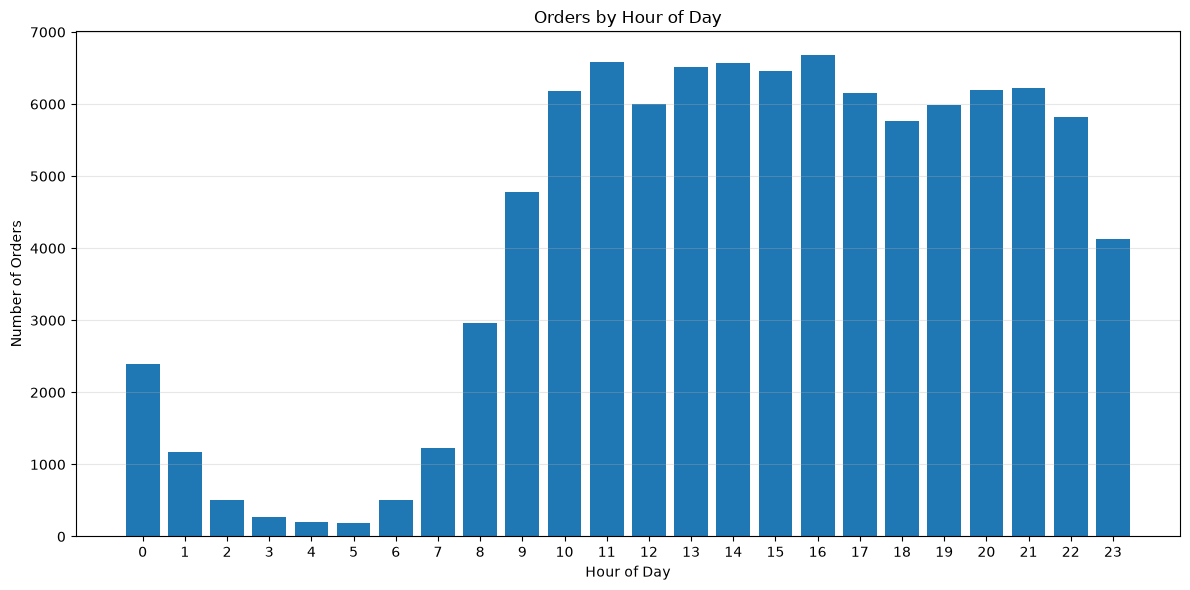

In [29]:
# Orders by Hour of Day

hourly_orders = (
    orders["hour_of_day"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

plt.bar(
    hourly_orders.index,
    hourly_orders.values
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Takeaway: Order activity is concentrated during the daytime and evening hours, while overnight and early-morning hours have substantially fewer orders, revealing a clear daily shopping pattern.

Daily shopping pattern: Customer activity is much lower during overnight and early-morning hours and rises substantially during the day and evening, which could help optimize promotional timing and operational planning.

In [30]:
# Level 3 — #10 Correlation Heatmap

# Calculate order value
order_values = (
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_value")
)

# Get review score for each order
order_reviews_summary = (
    order_reviews
    .groupby("order_id")["review_score"]
    .mean()
    .reset_index()
)

# Combine order value, delivery time, and review score
correlation_data = (
    orders[
        ["order_id", "delivery_time_days"]
    ]
    .merge(
        order_values,
        on="order_id",
        how="inner"
    )
    .merge(
        order_reviews_summary,
        on="order_id",
        how="inner"
    )
)

# Keep only valid observations
correlation_data = correlation_data.dropna(
    subset=[
        "order_value",
        "delivery_time_days",
        "review_score"
    ]
)

print("Correlation dataset:", correlation_data.shape)

print("\nVariables:")
print(
    correlation_data[
        ["order_value", "delivery_time_days", "review_score"]
    ].describe()
)

Correlation dataset: (95828, 4)

Variables:
        order_value  delivery_time_days  review_score
count  95828.000000        95828.000000  95828.000000
mean     136.795079           12.517302      4.156016
std      207.782117            9.460973      1.283755
min        0.850000            0.533333      1.000000
25%       45.900000            6.757465      4.000000
50%       86.250000           10.206250      5.000000
75%      149.900000           15.664757      5.000000
max    13440.000000          208.352083      5.000000


In [31]:
# Calculate correlation matrix

correlation_matrix = correlation_data[
    [
        "order_value",
        "delivery_time_days",
        "review_score"
    ]
].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(3))

Correlation Matrix:
                    order_value  delivery_time_days  review_score
order_value               1.000               0.055        -0.035
delivery_time_days        0.055               1.000        -0.334
review_score             -0.035              -0.334         1.000


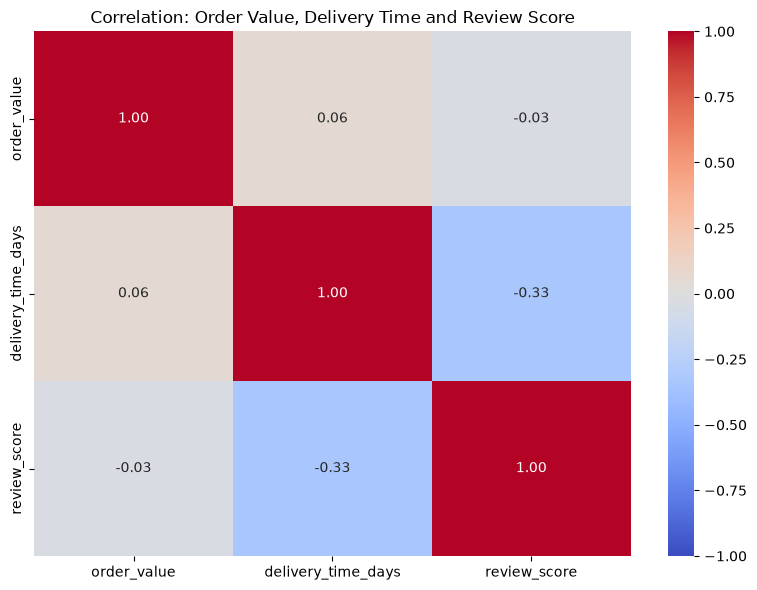

In [32]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation: Order Value, Delivery Time and Review Score")
plt.tight_layout()

plt.show()

Takeaway: Delivery time has a moderate negative correlation with review score (−0.334), suggesting that longer delivery times are associated with lower customer ratings, while order value shows almost no linear relationship with either delivery time or review score.

Delivery experience and satisfaction: The negative relationship between delivery time and review score suggests that delivery performance may influence customer satisfaction and should be investigated further in the business analysis.